# 10 — Scaling

Buying the search · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/10-scaling/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Required this week for
    more than rendering — the final section needs a GPU.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## The number we have been avoiding

Three weeks of training runs, and every one ended the same way: *not
enough steps*.

- Week 8: 30k steps. Learned not to fall.
- Week 9: 40k steps. Left one local optimum for a worse one.

A tuned locomotion run in the literature uses **150 million** steps.

We have been running **0.03%** of a real experiment and drawing
conclusions from it. Today we find out what that costs and how it is
bought.

------------------------------------------------------------------------

## The arithmetic of a run

A training run is $N$ environment steps. With $n$ environments each
stepping at $r$ steps per second, and a learner that needs $\ell$
seconds per update of $B$ steps:

$$T_{\text{wall}} \;=\; \frac{N}{n\,r} \;+\; \frac{N}{B}\,\ell
\qquad\text{(collect)} \qquad\;\; \text{(learn)}$$

The first term is what parallelism attacks. The second does not shrink
with $n$ — it is the serial part, and it caps the speed-up the way
Amdahl’s law says: with a fraction $s$ of the time spent learning, no
number of environments beats $1/s$.

Two things follow, and today measures both:

- $n$ only helps if the $n$ environments **really run at once**
- once collection is cheap, the learner’s $\ell$ is the wall, and that
  is why the network is small, the batch is large, and everything is
  compiled

------------------------------------------------------------------------

## Where the time goes

Not in the neural network. In the physics.

In [1]:
# Always upgrade, never "install only if the import fails". This course repo
# changes between labs, and a conditional install silently keeps a stale copy:
# `import soc4180` succeeds, the install is skipped, and a function added last
# week is missing. Upgrade BEFORE the first import -- pip cannot replace a
# module that is already loaded.
%pip install -q --upgrade "soc4180[rl] @ git+https://github.com/gnoejh/soc4180.git"
%pip install -q playground          # NOT playground[all]: that pulls jax[cuda12]

import soc4180, torch, mujoco_playground
print("soc4180", soc4180.__version__, "| playground OK")

Note: you may need to restart the kernel to use updated packages.

W:\soc4180GH\.venv\Scripts\pythonw.exe: No module named pip

Note: you may need to restart the kernel to use updated packages.
soc4180 0.1.0 | playground OK

W:\soc4180GH\.venv\Scripts\pythonw.exe: No module named pip

Two habits in that cell, both learned the hard way:

**Upgrade unconditionally.**
`try: import X / except ImportError: install X` can never deliver an
update — the import succeeds against a stale copy and the install never
runs. You then get an `AttributeError` for something that exists
perfectly well in the repository.

**Install before importing.** pip rewrites files on disk; it cannot
replace a module the interpreter has already loaded.

In [2]:
import time, warnings
import numpy as np
warnings.filterwarnings("ignore")
from soc4180.envs import G1WalkEnv

env = G1WalkEnv(); env.reset(seed=0)
action = np.zeros(12, dtype=np.float32)

t0 = time.time(); n = 3000
for _ in range(n):
    _, _, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        env.reset()
single = n / (time.time() - t0)

print(f"one environment : {single:8.0f} control steps/s")
print(f"                  {single*env.decimation:10,.0f} physics steps/s "
      f"({env.decimation} per control step)")
print(f"150M steps at this rate: {150e6/single/3600:6.1f} hours "
      f"({150e6/single/86400:.1f} days)")

one environment :     1284 control steps/s
                      12,843 physics steps/s (10 per control step)
150M steps at this rate:   32.4 hours (1.4 days)

**More than a day of compute for one run.** And a real study needs
several seeds.

------------------------------------------------------------------------

## The obvious idea, and why it fails

Run many environments at once. Stable-Baselines3 offers `DummyVecEnv`:

In [3]:
from stable_baselines3.common.vec_env import DummyVecEnv

dummy = {}
for k in (1, 4, 16):
    vec = DummyVecEnv([lambda: G1WalkEnv() for _ in range(k)])
    vec.reset(); acts = np.zeros((k, 12), dtype=np.float32)
    t0 = time.time(); m = 400
    for _ in range(m):
        vec.step(acts)
    dummy[k] = m * k / (time.time() - t0)
    print(f"  DummyVecEnv, {k:2d} envs : {dummy[k]:7.0f} steps/s")
    vec.close()

  DummyVecEnv,  1 envs :    1178 steps/s
  DummyVecEnv,  4 envs :    1225 steps/s
  DummyVecEnv, 16 envs :    1229 steps/s

Sixteen environments, **the same throughput as one**.

`DummyVecEnv` steps them *in a loop*. It batches the policy’s forward
pass, which was never the bottleneck. The physics still runs one
environment at a time on one core.

> “Vectorised” does not mean “parallel”.

------------------------------------------------------------------------

## Real parallelism, and its ceiling

`SubprocVecEnv` puts each environment in its own process, so the physics
really does run at the same time:

In [4]:
from stable_baselines3.common.vec_env import SubprocVecEnv
import os

print(f"CPU cores available here: {os.cpu_count()}\n")
subproc = {}
for k in (2, 4, 8):
    vec = SubprocVecEnv([G1WalkEnv for _ in range(k)])
    vec.reset(); acts = np.zeros((k, 12), dtype=np.float32)
    for _ in range(10):
        vec.step(acts)                      # warm up the workers
    t0 = time.time(); m = 300
    for _ in range(m):
        vec.step(acts)
    subproc[k] = m * k / (time.time() - t0)
    print(f"  SubprocVecEnv, {k} envs : {subproc[k]:7.0f} steps/s")
    vec.close()

CPU cores available here: 36

  SubprocVecEnv, 2 envs :    1637 steps/s
  SubprocVecEnv, 4 envs :    3090 steps/s
  SubprocVecEnv, 8 envs :    5487 steps/s

This scales — until you run out of cores. **A Colab CPU runtime has
two.**

Even at a perfect 8× we would still need four hours per run, and the
tuned config asks for **8192** environments. There are not enough cores
in the building.

------------------------------------------------------------------------

## Vectorised against parallel, drawn

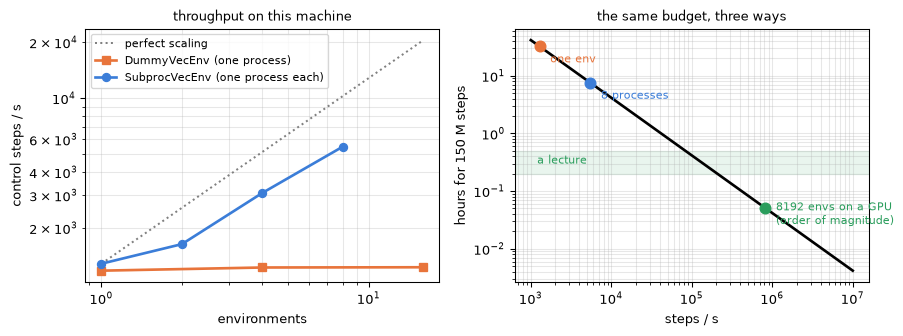

In [5]:
import matplotlib.pyplot as plt

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.6))
ks = sorted(set(dummy) | set(subproc) | {1})
ax0.loglog(ks, [single * k for k in ks], ":", color="0.5", label="perfect scaling")
ax0.loglog(sorted(dummy), [dummy[k] for k in sorted(dummy)], "s-", color="#e8743b", lw=2, label="DummyVecEnv (one process)")
ax0.loglog([1] + sorted(subproc), [single] + [subproc[k] for k in sorted(subproc)], "o-", color="#3b7dd8", lw=2, label="SubprocVecEnv (one process each)")
ax0.set_xlabel("environments"); ax0.set_ylabel("control steps / s"); ax0.legend(fontsize=8); ax0.grid(alpha=0.3, which="both")
ax0.set_title("throughput on this machine", fontsize=10)
rates = np.logspace(3, 7, 100)
ax1.loglog(rates, 150e6 / rates / 3600, color="k", lw=2)
for r_, label, col in ((single, "one env", "#e8743b"), (max(subproc.values()), f"{max(subproc)} processes", "#3b7dd8"),
                       (8192 * 100, "8192 envs on a GPU\n(order of magnitude)", "#2a9d5c")):
    ax1.plot(r_, 150e6 / r_ / 3600, "o", ms=8, color=col)
    ax1.annotate(label, (r_, 150e6 / r_ / 3600), xytext=(8, -12), textcoords="offset points", fontsize=8, color=col)
ax1.axhspan(0.2, 0.5, color="#2a9d5c", alpha=0.1); ax1.text(1.2e3, 0.3, "a lecture", fontsize=8, color="#2a9d5c")
ax1.set_xlabel("steps / s"); ax1.set_ylabel("hours for 150 M steps"); ax1.grid(alpha=0.3, which="both")
ax1.set_title("the same budget, three ways", fontsize=10)
fig.tight_layout(); plt.show()

The orange line is flat: sixteen environments, one core. The blue one
climbs until the cores run out. The green dot is where the tuned
configurations live, and no amount of blue reaches it.

------------------------------------------------------------------------

## Physics on the GPU

The way out is not more cores. It is a different kind of processor.

**MJX** is MuJoCo rewritten in JAX. The same model, the same contact
solver — but expressed so that XLA can compile it and run **thousands of
copies at once** on a GPU.

Two ideas make it work:

- **`jit`** — compile the whole step function once, ahead of time,
  instead of interpreting Python 500 times a second
- **`vmap`** — take a function written for *one* robot and vectorise it
  over a batch dimension, so 8192 robots step in one GPU kernel launch

The price is real: everything must be expressible as fixed-shape array
operations. **No Python branching, no variable-length loops, no early
exit** — which is why an MJX environment reads so differently from the
one we wrote.

------------------------------------------------------------------------

## `vmap`, drawn

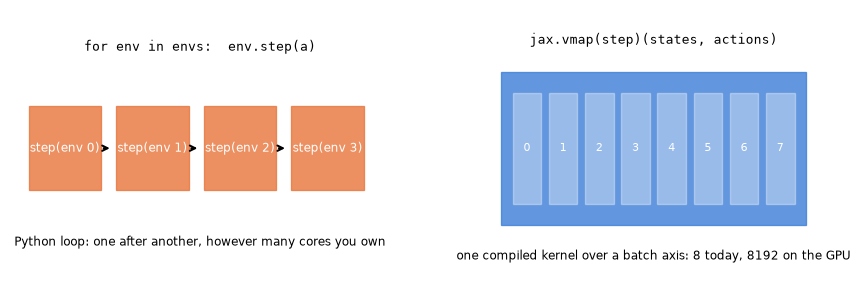

In [6]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.2))
for ax in (ax0, ax1):
    ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 4)
for i in range(4):
    ax0.add_patch(plt.Rectangle((0.5 + 2.3 * i, 1.4), 1.9, 1.2, color="#e8743b", alpha=0.8))
    ax0.text(1.45 + 2.3 * i, 2.0, f"step(env {i})", ha="center", va="center", fontsize=9, color="w")
    if i < 3:
        ax0.annotate("", xy=(2.7 + 2.3 * i, 2.0), xytext=(2.4 + 2.3 * i, 2.0), arrowprops=dict(arrowstyle="->", lw=1.5))
ax0.text(5, 0.6, "Python loop: one after another, however many cores you own", ha="center", fontsize=9)
ax0.text(5, 3.4, "for env in envs:  env.step(a)", ha="center", fontsize=10, family="monospace")
ax1.add_patch(plt.Rectangle((1.0, 0.9), 8.0, 2.2, color="#3b7dd8", alpha=0.8))
for i in range(8):
    ax1.add_patch(plt.Rectangle((1.3 + 0.95 * i, 1.2), 0.75, 1.6, color="w", alpha=0.35))
    ax1.text(1.675 + 0.95 * i, 2.0, f"{i}", ha="center", va="center", fontsize=8, color="w")
ax1.text(5, 0.4, "one compiled kernel over a batch axis: 8 today, 8192 on the GPU", ha="center", fontsize=9)
ax1.text(5, 3.5, "jax.vmap(step)(states, actions)", ha="center", fontsize=10, family="monospace")
fig.tight_layout(); plt.show()

The price, again: every robot must take the same instructions. No `if`,
no early exit, no variable-length anything. The batch is one array.

------------------------------------------------------------------------

## What the professionals actually run

`mujoco_playground` ships tuned configurations. These are read from the
library, not quoted from memory:

In [7]:
from mujoco_playground.config import locomotion_params

for name in ("BerkeleyHumanoidJoystickFlatTerrain", "Op3Joystick"):
    cfg = locomotion_params.brax_ppo_config(name)
    print(f"{name}")
    print(f"    timesteps   {cfg['num_timesteps']:>12,}")
    print(f"    parallel envs {cfg['num_envs']:>10,}")
    print(f"    batch size  {cfg['batch_size']:>12}")
    print(f"    discounting {cfg['discounting']:>12}")

BerkeleyHumanoidJoystickFlatTerrain
    timesteps    150,000,000
    parallel envs      8,192
    batch size           256
    discounting         0.97
Op3Joystick
    timesteps    100,000,000
    parallel envs      8,192
    batch size           256
    discounting         0.97

8192 environments in parallel, 150 million steps. Our entire Week 9
experiment was **0.027%** of one of these.

------------------------------------------------------------------------

## A detail worth noticing

In [8]:
cfg = locomotion_params.brax_ppo_config("BerkeleyHumanoidJoystickFlatTerrain")
net = dict(cfg["network_factory"])
for k, v in net.items():
    print(f"  {k:28s} {v}")

  policy_hidden_layer_sizes    (512, 256, 128)
  policy_obs_key               state
  value_hidden_layer_sizes     (512, 256, 128)
  value_obs_key                privileged_state

Look at the last two lines. The **policy** reads `state`; the **value
function** reads `privileged_state`.

That is the asymmetric actor–critic from Week 6, in production. The
critic is allowed to see things no real robot can measure — body height,
contact forces, terrain — because the critic is thrown away after
training. The policy sees only what an IMU and joint encoders provide,
so it remains deployable.

**The discipline we imposed in Week 6 is exactly what the state of the
art does.**

------------------------------------------------------------------------

## Three things that will bite you

Every one of these was hit while preparing this lab, and none is your
code being wrong.

**1. `ModuleNotFoundError: mujoco_playground`.** It is not part of
`soc4180[rl]`; install `playground` separately.

**2. `AttributeError: type object 'int' has no attribute 'WARP'`.** The
env config defaults to `impl="warp"`, the newer MJWarp backend, which
needs the separate `mujoco-warp` package. Override to **`impl="jax"`**.

**3. Two removed JAX APIs.** Depending on which library trips first you
get

    AttributeError: jax.core.get_opaque_trace_state was ... removed in JAX v0.11.0
    AttributeError: jax.device_put_replicated is deprecated

The first is **flax**, the second is **brax**. Both still call APIs that
JAX removed in 0.11, and brax requires only `jax>=0.4.6` — no upper
bound — so pip installs a broken combination by default. **Colab’s
preinstalled JAX is 0.11, so it is broken out of the box.**

------------------------------------------------------------------------

## Repairing it in three lines

Two fixes exist. **Pinning `jax==0.9.2`** — the newest release still
carrying both functions — works, but on Colab it means a large download
*and* a runtime restart on every fresh session, because pip cannot
replace a module Python has already imported.

Cheaper: put the two functions back. JAX’s own deprecation messages name
their replacements.

In [9]:
import jax
import jax.numpy as jnp
import jax.core, jax.extend.core

# Written out in full rather than called from soc4180, deliberately: this cell
# repairs a broken environment, so it must not itself depend on a package
# install having gone through. (The same code is in soc4180/jax_compat.py.)

# Where this function lives varies between JAX builds -- the deprecation message
# points at jax.extend.core, but it is not always there. Search, never assume,
# and never let the repair cell itself raise.

import importlib

def _find(name, modules):
    for mod in modules:
        try:
            found = getattr(importlib.import_module(mod), name, None)
        except Exception:
            continue
        if found is not None:
            return found, mod
    return None, None

fn, where = _find("get_opaque_trace_state",
                  ["jax.extend.core", "jax._src.core", "jax.core"])
if fn is None:
    print("get_opaque_trace_state: not found anywhere - flax may fail")
else:
    jax.core.get_opaque_trace_state = fn                      # flax looks here
    print(f"get_opaque_trace_state: patched from {where}")

if not hasattr(jax, "device_put_replicated"):                 # brax looks here
    def device_put_replicated(x, devices):
        stacked = jax.tree.map(lambda v: jnp.stack([jnp.asarray(v)] * len(devices)), x)
        return jax.device_put(stacked, devices[0]) if len(devices) == 1 else stacked
    jax.device_put_replicated = device_put_replicated
    print("device_put_replicated : patched")
else:
    print("device_put_replicated : already present")

print("jax", jax.__version__, "| devices:", jax.devices())   # want a CudaDevice

get_opaque_trace_state: patched from jax.extend.core
device_put_replicated : already present
jax 0.11.1 | devices: [CpuDevice(id=0)]

`get_opaque_trace_state` simply moved to `jax.extend.core`.
`device_put_replicated` stacked an array once per device, which is a few
lines of `jnp.stack`. Neither is deep magic, and this is the kind of
patch you will write repeatedly in this field.

Note it is written out here rather than imported from `soc4180`. A cell
whose job is repairing a broken environment should not depend on a
package install having succeeded — that just adds a second thing that
can fail.

**Pin versions in a course repo and bump them once a semester.** Half of
these failures are simply the calendar moving.

------------------------------------------------------------------------

## Running it

This needs a **GPU runtime**, and it will not run on a Windows machine
at all — JAX publishes CUDA wheels for Linux only.

In [10]:
import functools
from mujoco_playground import registry, wrapper
from mujoco_playground.config import locomotion_params
from brax.training.agents.ppo import train as ppo
from brax.training.agents.ppo import networks as ppo_networks

env_name = "BerkeleyHumanoidJoystickFlatTerrain"

# impl="jax" picks the MJX backend. The config default is "warp" (MJWarp), which
# needs the separate `mujoco-warp` package; without it registry.load dies with
#   AttributeError: type object 'int' has no attribute 'WARP'
env = registry.load(env_name, config_overrides={"impl": "jax"})

params = dict(locomotion_params.brax_ppo_config(env_name))
net = params.pop("network_factory")
params["network_factory"] = functools.partial(ppo_networks.make_ppo_networks, **net)
params.update(num_timesteps=5_000_000,    # ~3% of the tuned budget; see below
              num_envs=2048,              # fits a T4; an A100 can take more
              num_evals=10)               # progress every ~500k steps

# Without a progress_fn brax prints NOTHING until the whole run finishes, which
# for a lab means staring at a blank cell for ten minutes wondering if it hung.
import time
start = time.time()

def progress(step, metrics):
    print(f"{step:>10,} steps | {time.time()-start:6.0f}s "
          f"| reward {metrics.get('eval/episode_reward', float('nan')):8.2f} "
          f"| length {metrics.get('eval/avg_episode_length', float('nan')):6.1f}")

make_inference, weights, metrics = ppo.train(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,   # a playground env is not a brax env
    progress_fn=progress,
    **params,
)
print(f"\ntotal {time.time()-start:.0f}s for {params['num_timesteps']:,} steps")

`registry.load` clones its **own** copy of Menagerie on first call —
about 40 seconds, separate from the copy `soc4180` uses.

------------------------------------------------------------------------

## Track A and Track B

**The first line takes the longest.** Brax compiles the entire training
loop through XLA before a single step runs, so expect a minute or two of
silence before the first progress line — then the rest come quickly.
That gap is compilation, not a hang.

**Calibrate the budget yourself.** 5M steps is a starting point. Read
the seconds-per-step from the progress output and scale `num_timesteps`
so the run lands where you want it; an A100 is substantially faster than
the T4 this figure was chosen for.

------------------------------------------------------------------------

## Track A and Track B

**Track A — required, ≤15 minutes.** Run the truncated configuration
above. Success is **not** a walking robot. Success is:

> episode reward and episode length both trending upward, and a rollout
> that shows a recognisable attempt at a gait.

**Track B — optional.** The full 150M-step budget, launched at the start
of the lab and collected at the end, or run overnight with checkpoints
saved to Drive.

Colab disconnects. **Checkpoint every evaluation**, or a run that dies
at minute 80 of 90 leaves you with nothing.

------------------------------------------------------------------------

## Reading a learning curve

You will be judged on the diagnosis, not the policy. Four shapes to
recognise:

| Curve | Likely cause |
|------------------------------------|------------------------------------|
| Flat from the start | broken observation, wrong action scale, or no gradient reaching the policy |
| Rises then collapses | learning rate too high, or the exploration bug from Week 8 |
| Rises then plateaus below target | local optimum — Week 9’s standing robot |
| Rises smoothly, slowly | it is working; you need more steps |

Always plot **episode length** alongside reward. A rising reward with
flat episode length usually means the policy found a way to score
without surviving — and that is a reward bug, not a training one.

------------------------------------------------------------------------

## The four shapes, sketched

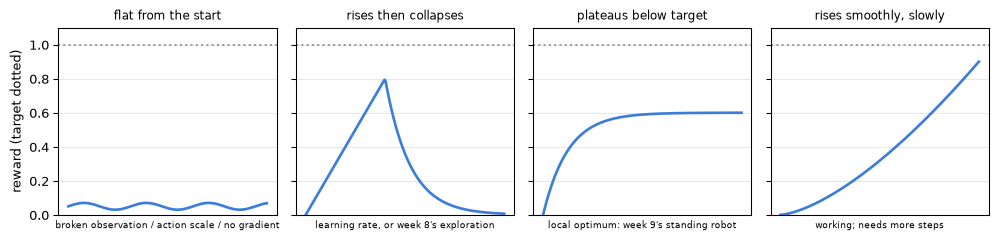

In [11]:
t = np.linspace(0, 1, 200)
shapes = [("flat from the start", 0.05 + 0.02 * np.sin(20 * t), "broken observation / action scale / no gradient"),
          ("rises then collapses", np.where(t < 0.4, 0.8 * t / 0.4, 0.8 * np.exp(-8 * (t - 0.4))), "learning rate, or week 8's exploration"),
          ("plateaus below target", 0.6 * (1 - np.exp(-8 * t)), "local optimum: week 9's standing robot"),
          ("rises smoothly, slowly", 0.9 * t ** 1.5, "working; needs more steps")]
fig, axs = plt.subplots(1, 4, figsize=(10.5, 2.6), sharey=True)
for ax, (name, y, cause) in zip(axs, shapes):
    ax.plot(t, y, lw=2, color="#3b7dd8"); ax.axhline(1.0, color="0.6", ls=":")
    ax.set_title(name, fontsize=9); ax.set_xlabel(cause, fontsize=7); ax.set_xticks([]); ax.grid(alpha=0.3)
axs[0].set_ylabel("reward (target dotted)"); axs[0].set_ylim(0, 1.1)
fig.tight_layout(); plt.show()

Sketches, not data: the point is the *shape*. Plot episode length
underneath each, always.

------------------------------------------------------------------------

## What the budget actually buys

| Budget | What we saw |
|------------------------------------|------------------------------------|
| 30k steps (Week 8) | learns not to fall; scores the standing baseline |
| 40k steps (Week 9) | leaves the standing optimum, falls over backwards |
| 15M steps (today, Track A) | a recognisable gait attempt |
| 150M steps (tuned) | robust joystick-controlled walking |

Three orders of magnitude separate the top row from the bottom, and
nothing else about the algorithm changes. **PPO was never the
limitation.**

Our conclusions from Weeks 8 and 9 were not wrong — but they were
conclusions about *underfunded* runs, and it is worth being honest about
which findings survive a real budget.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/10-scaling/lab_many.py
```

`N_ROBOTS` copies of the G1 in **one** scene — one model, one `mj_step`,
one controller driving all of them — walking side by side in the viewer.
`+`/`-` add and remove robots, `F` randomises each one’s friction and
mass (they drift apart within steps: week 11 in one key), `P` benchmarks
1, 2, 4 and 8 processes, and `ENTER` prints robot-steps per second
against the student’s `predict_rate`.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | `ENTER`, then `+` `+` `+` | a prediction for one process, written into `predict_rate`, then checked |
| 2 | `P` | four numbers, and the core count that explains where they stop |
| 3 | hours for 150 M at the best rate | the arithmetic of the first slide, done on their own machine |
| 4 | `F` | robots that diverge; what a policy trained on all of them would have to learn |
| 5 | `+` until 0.25× real time | the cost of one environment, in milliseconds |

------------------------------------------------------------------------

## Exercises

1.  **Measure your own ceiling.** Run the `SubprocVecEnv` sweep on
    Colab. How many cores do you get, and where does throughput stop
    improving?
2.  **Do the arithmetic.** At your measured CPU rate, how long is 150M
    steps? How many GPU-equivalents of CPU would you need?
3.  **Track A.** Run the truncated MJX configuration. Plot reward *and*
    episode length. Classify the curve using the table above.
4.  **Halve the environments.** Set `num_envs` to 1024 and then 4096 at
    a fixed step budget. Does wall-clock scale as you expect? What does
    that say about where the GPU time goes?
5.  **Break it deliberately.** Set the learning rate to 3e-2 and
    describe the curve’s shape before looking.
6.  **Checkpoint discipline.** Write a callback that saves to Drive
    every evaluation and reloads on restart. Test it by interrupting the
    run.

------------------------------------------------------------------------

## Next week

**Week 11 — domain randomization.** With a real budget available, the
question changes from *can it learn* to *will it survive anything other
than the exact simulator it learned in*.

We randomise mass, friction, and actuation during training, and measure
what robustness costs.